# Binary Mask Segmentation
- **Author:** Juan Pablo Triana Martinez
- **Date:** 2026-03-31

This notebook is a step-by-step process in order to read from `models` folder, a specific desired **binary test** region model, and then proceed to implement from `src/utils`, the necessary text evaluation metrics.

The following are presented in this notebook:
- Read a specific existing subset dataset.
- Obtain the test `torch.utils.DataLoader` from `src/data` of the subset dataset
- Let's load the desired binary model.
- Batch binary hard metrics from `get_binary_metrics()`, which include:
    * accuracy
    * precision
    * recall
    * f1_score
    * iou_pixel
    * dice_pixel
- Scatter plots of each of them to see the values.
- Average of said `get_binary_metrics()`
- Batch binary soft metrics from `binary_soft_metrics()` which include:
    * IoU_region
    * DsC_region
- Scatter plots of each of them to see the values
- Average of said `binary_soft_metrics()`.

The purpose of this notebook is to use it as a tool, to visualize the results of different binary models. 

The objective is to perform the following experiments:

| weight_ce | weight_dice | Rationale |
|--------|----------|--------------|
| 1.0 | 0.0 | Baseline - pure  BCE. no Dice |
| 1.0 | 0.25 | Light Dice regularization |
| 1.0 | 0.5  | Balanced towards BCE (your default) |
| 1.0 | 0.75 | BCE + Dice - dominant |
| 1.0 | 1.0  | Equal - weighting |

After doing this, we will see the following as well:
| weight_ce | weight_dice | Rationale |
|--------|----------|--------------|
| 0.0 | 1.0 | Baseline - pure  Dice. no BCE/CE |
| 0.25 | 1.0 | Light BCE regularization |
| 0.5 | 1.0  | Balanced towards Dice (your default) |
| 0.75 | 1.0 | Dice + BCE - dominant |

## 1. Read a specific subset dataset

In [ ]:
from pathlib import Path
import sys
import torch
from torchvision import transforms
from typing import Dict

In [24]:
# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

In [25]:
from src.data import get_dataloaders_text_detection

In [26]:
DATA_PATH = working_path / "data"
SUBSET_DATANAME= "google_collab_seed_86"

In [ ]:
# Default settings from training scripts
BATCH_SIZE = 8
NEW_HEIGHT = 512
NEW_WIDTH = 512
NUM_WORKERS = 0
PIN_MEMORY = False

# NOTE: linknet_binary_v1_1.pth was trained without input normalization.
# Passing explicit transforms to match the original training setup so that
# model predictions remain correct. For NEW models trained with normalization,
# remove these explicit transforms and let the dataloader auto-compute them.
eval_transform = transforms.Compose([
    transforms.Resize((NEW_HEIGHT, NEW_WIDTH)),
    transforms.ToTensor(),
])

binary_train_dl, binary_val_dl, binary_test_dl = get_dataloaders_text_detection(
    data_path=DATA_PATH,
    dataset_name=SUBSET_DATANAME,
    mask_type="binary-text",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    train_transform=eval_transform,
    val_transform=eval_transform,
    test_transform=eval_transform,
)

## 2. Let's load a binary model

In [28]:
# Model name, this can change many times.
model_name = "linknet_binary_v1_1.pth"
model_path = working_path / "models" / model_name
model_path.exists()

True

In [30]:
from src.models import LinknetModel

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
binary_text_model = LinknetModel(Cin=3, N = 1).to(device)

In [32]:
# Let's load the trained google collab model
binary_text_model.load_state_dict(torch.load(f = model_path, map_location=device))

<All keys matched successfully>

## 3 & 4 Let's obtain the binary metrics, across All the images
For this we will be using the following:
1. `get_binary_metrics()` function from `src/utils/text_detection_eval_metrics.py`.
2. `get_soft_metrics()` with `is_binary = True`, in order to obtain the total semantic metrics.

These functions are set in a way that are used across batches. However, we can create a new function that we are gonna call `get_images_metrics`, which will iterate across each batch, and compare and get per image metrics.

In [66]:
# Imports for all nce
from src.utils import get_binary_metrics, get_soft_metrics
from collections import defaultdict
from torch.utils.data import DataLoader
from typing import Tuple, List
from tqdm import tqdm
import torch.nn as nn

def get_images_metrics(
        dataloder: DataLoader,
        model: nn.Module) -> Dict[str, list]:
    
    # Let's now define the total_metrics dictionary
    total_metrics: Dict[str, list] = defaultdict(list)

    # Let's set the model to eval mode
    model.eval()

    # Let's use torch.infetence_mode() to not keep gradients, and fast inference
    with torch.inference_mode():
        for batch, (X_imgs, X_masks, X_metadata) in tqdm(enumerate(binary_test_dl), desc= "Iterating across batches...", total=len(dataloder)):
            # Get the images and masks to perform analysis
            X_imgs = X_imgs.to(device)
            X_masks = X_masks.to(device)

            # Get the logits of the model 
            X_logits = model(X_imgs)

            # Now let's iterate across each image
            for b in range(X_logits.shape[0]):

                # Let's get the rest of the logits
                X_logits_b = X_logits[b:b+1]
                X_masks_b = X_masks[b:b+1]
                X_metadata_b = X_metadata["file_name"][b]
                X_imgs_b = X_imgs[b]

                # Let's get the pixel metrics and soft binary metrics
                pixel_metrics_b = get_binary_metrics(X_logits_b, X_masks_b)
                region_metrics_b = get_soft_metrics(X_logits_b, X_masks_b, is_binary=True)

                # Append all the soft and hard pixel metrics
                for k, v in pixel_metrics_b.items():
                    total_metrics[k].append(float(v))
                for k, v in region_metrics_b.items():
                    total_metrics[k].append(float(v.mean()))

                # Now let's append the names of the files
                total_metrics["files_names"].append(X_metadata_b)

                # Now let's append the imgs, logits, masks
                total_metrics["imgs"].append(X_imgs_b)
                total_metrics["masks"].append(X_masks_b)
                total_metrics["logits"].append(X_logits_b)

    return total_metrics

In [68]:
total_metrics = get_images_metrics(
    dataloder=binary_test_dl,
    model=binary_text_model)

Iterating across batches...: 100%|██████████| 13/13 [00:15<00:00,  1.22s/it]


## 4.1 Plot all of the total metrics: Hard + soft pixel metrics.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_per_sample(metrics_dict: Dict[str, np.ndarray], title: str = "") -> None:
    """Line plot of each metric across the batch dimension."""
    n = len(metrics_dict)
    fig, axs = plt.subplots(nrows=n, ncols=1, figsize=(n, 2 * n))
    if n == 1:
        axs = [axs]
    for ax, (name, values) in zip(axs, metrics_dict.items()):
        ax.plot(values, marker="o")
        ax.set_title(name)
        ax.set_xlabel("Sample index")
        ax.set_ylabel("Value")
        ax.set_ylim(0, 1.05)
    if title:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

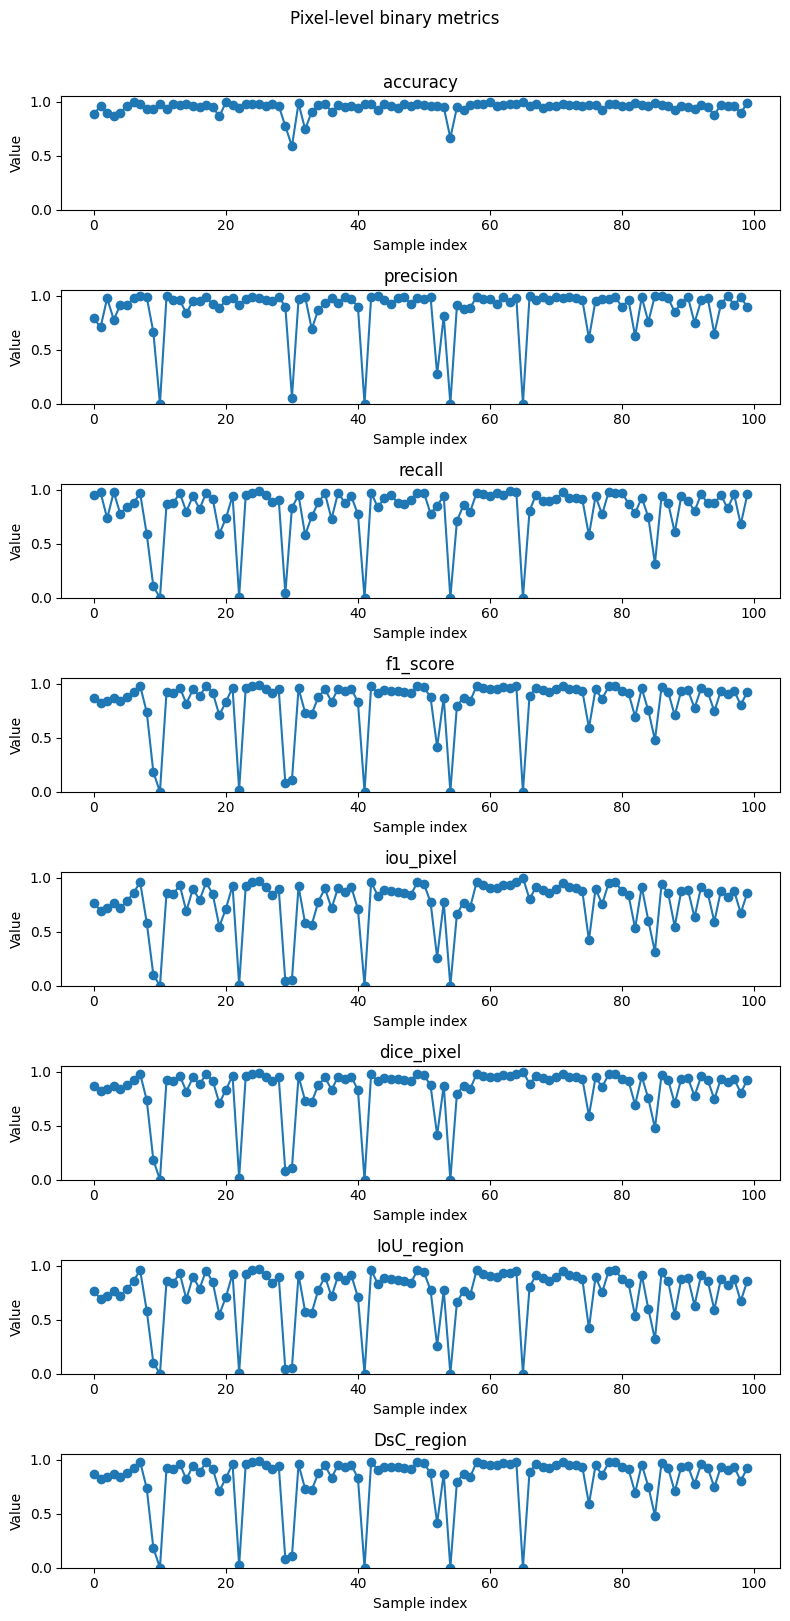

In [69]:
# Let's get all metrics without file_names
numeric_metrics = {key:val for key, val in total_metrics.items() if key not in ["files_names", "imgs", "masks", "logits"]}
plot_metrics_per_sample(numeric_metrics, title="Pixel-level binary metrics")

## 5. Let's get the average of the binary metrics
Now let's get the average of the total binary numeric metrics!

In [70]:
# Let's get the average metrics
average_metrics = {k : np.mean(np.array(v, dtype=np.float32)).item() for k, v in numeric_metrics.items()}
average_metrics

{'accuracy': 0.9473890662193298,
 'precision': 0.8752009868621826,
 'recall': 0.8137484192848206,
 'f1_score': 0.8230912685394287,
 'iou_pixel': 0.7628004550933838,
 'dice_pixel': 0.8330914378166199,
 'IoU_region': 0.7517306804656982,
 'DsC_region': 0.8224835991859436}

## 6. Now, let's plot the images with the worst set measurement.
This function will be called `plot_worst_images` which will take the `numeric_metrics` dictionary, and the `average_metrics` dictionary.
Based on setting it to one specific key, it will iterate across all the images and **Only plot the images below the average**.

In [86]:
from PIL import Image
def plot_worst_images(num_metrics: Dict[str, list],
                      avg_metrics: Dict[str, float],
                      total_imgs: List[torch.Tensor],
                      total_masks: List[torch.Tensor],
                      total_logits: List[torch.Tensor],
                      key_metric:str) -> None:
    
    assert key_metric in num_metrics.keys(), "This key metric doesnt exist"

    avg_threshold = avg_metrics[key_metric]
    for i, metric in tqdm(enumerate(num_metrics[key_metric]), desc="Iterating across all images...", total=len(num_metrics[key_metric])):
        if metric <= avg_threshold:
            fig, axs = plt.subplots(nrows=1, ncols=3, figsize = (15, 5))

            fig.suptitle(f"{key_metric} figure: {metric:.3f} < avg_threshold: {avg_threshold:.3f}")
            # --- Image ---
            img = total_imgs[i].permute(1, 2, 0).cpu()
            axs[0].imshow(img)
            axs[0].set_title("Image")
            axs[0].axis("off")

            # --- Ground Truth ---
            gt = total_masks[i].squeeze().cpu()
            axs[1].imshow(gt, cmap="gray")
            axs[1].set_title("Ground Truth")
            axs[1].axis("off")

            # --- Prediction ---
            pred = total_logits[i].squeeze().cpu()

            # If logits → convert to probabilities / binary
            if pred.max() > 1 or pred.min() < 0:
                pred = torch.sigmoid(pred)

            pred = (pred > 0.5).float()

            axs[2].imshow(pred, cmap="gray")
            axs[2].set_title("Prediction")
            axs[2].axis("off")
            plt.show()
    

Iterating across all images...:   0%|          | 0/100 [00:00<?, ?it/s]

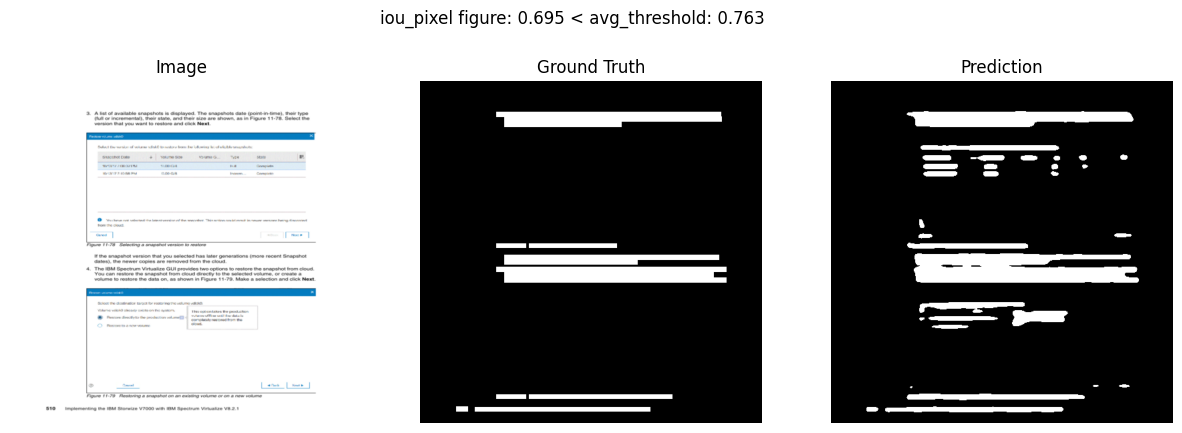

Iterating across all images...:   2%|▏         | 2/100 [00:00<00:12,  7.73it/s]

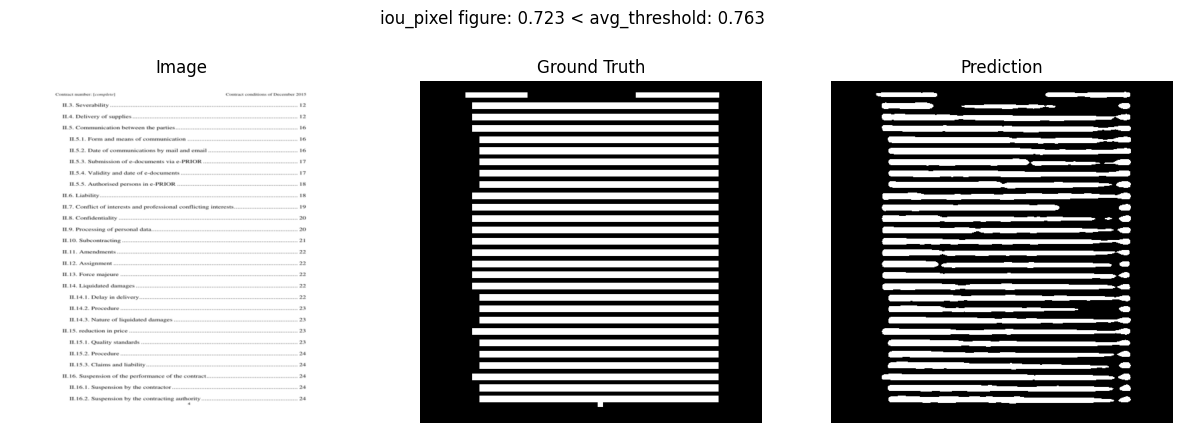

Iterating across all images...:   3%|▎         | 3/100 [00:00<00:17,  5.67it/s]

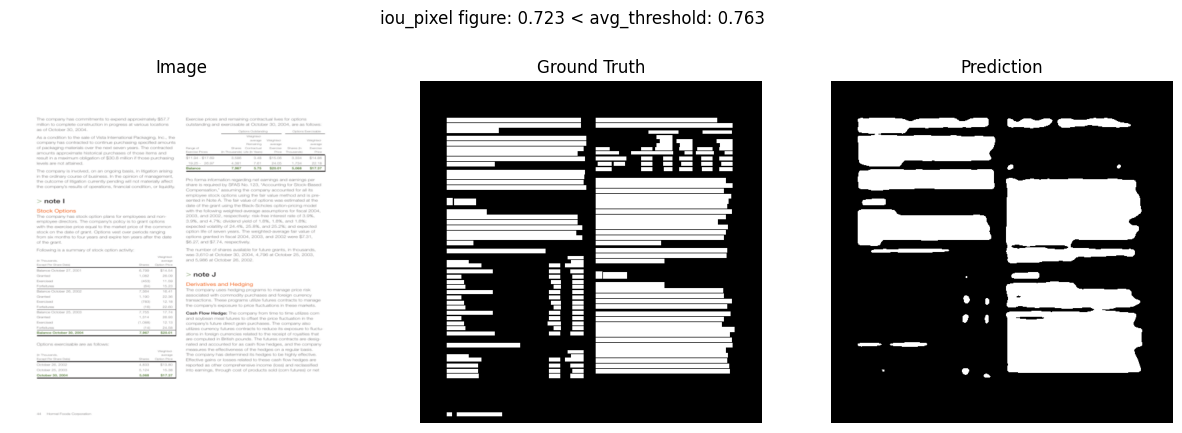

Iterating across all images...:   5%|▌         | 5/100 [00:00<00:14,  6.53it/s]

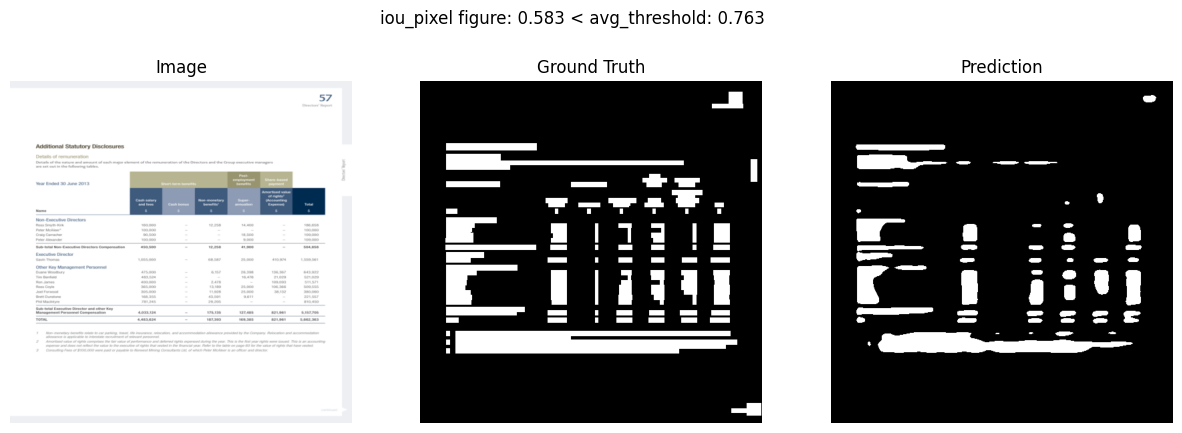

Iterating across all images...:   9%|▉         | 9/100 [00:01<00:09, 10.06it/s]

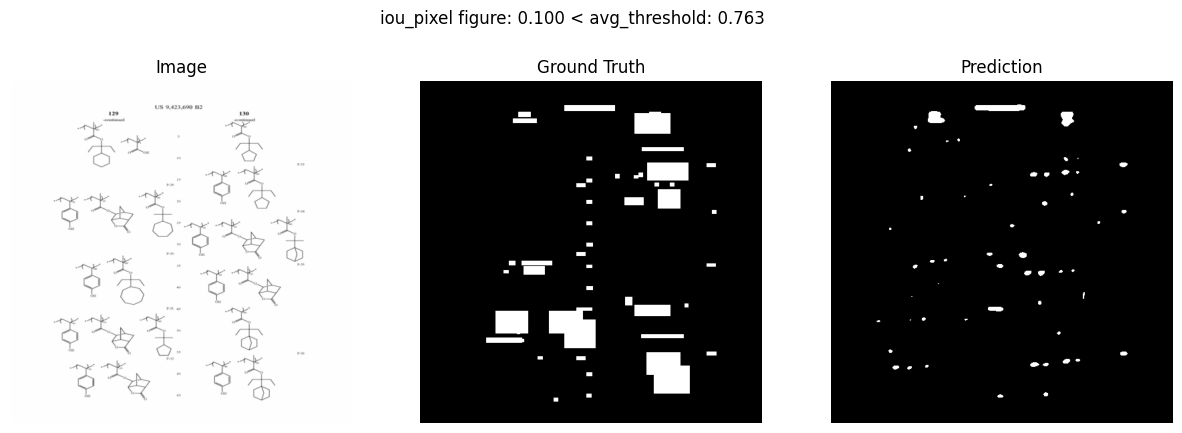

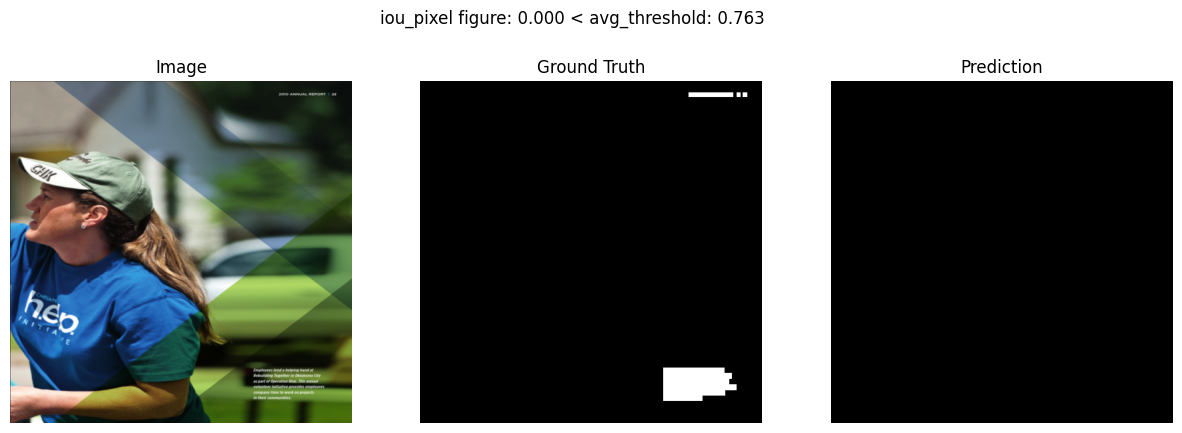

Iterating across all images...:  11%|█         | 11/100 [00:01<00:13,  6.69it/s]

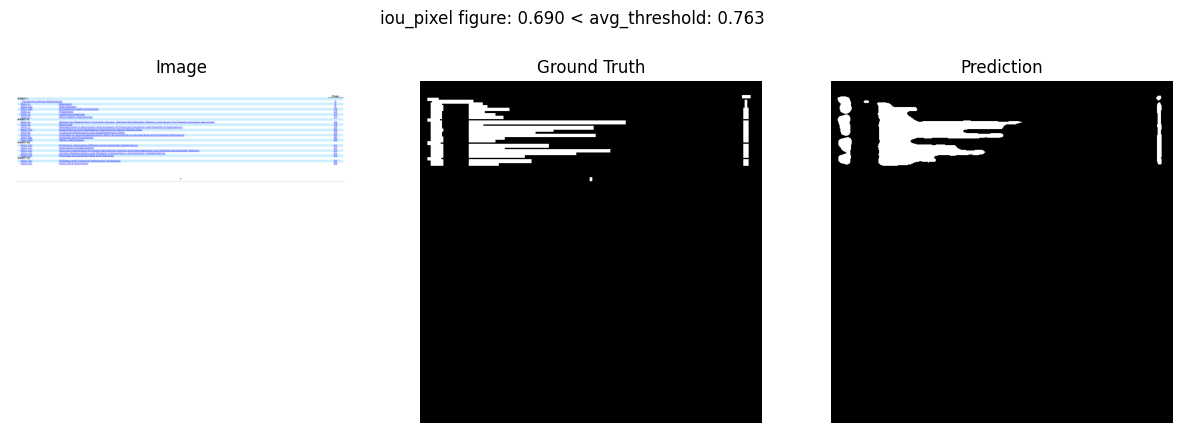

Iterating across all images...:  15%|█▌        | 15/100 [00:02<00:12,  6.57it/s]

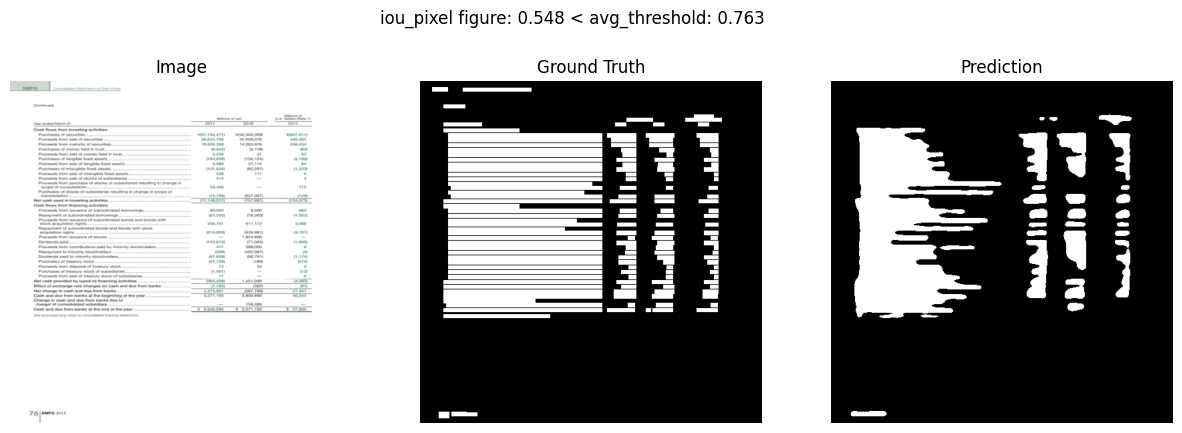

Iterating across all images...:  20%|██        | 20/100 [00:02<00:08,  9.47it/s]

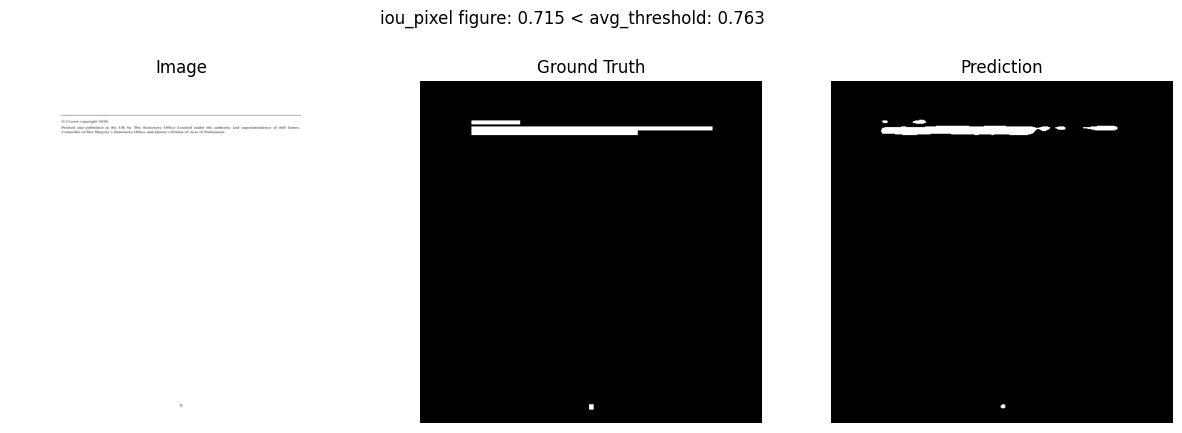

Iterating across all images...:  22%|██▏       | 22/100 [00:02<00:08,  9.19it/s]

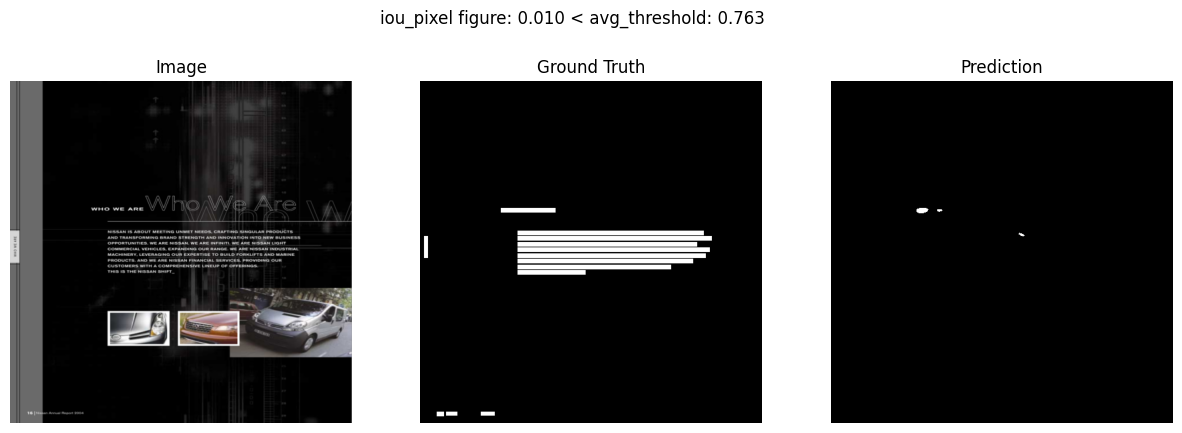

Iterating across all images...:  24%|██▍       | 24/100 [00:02<00:08,  8.85it/s]

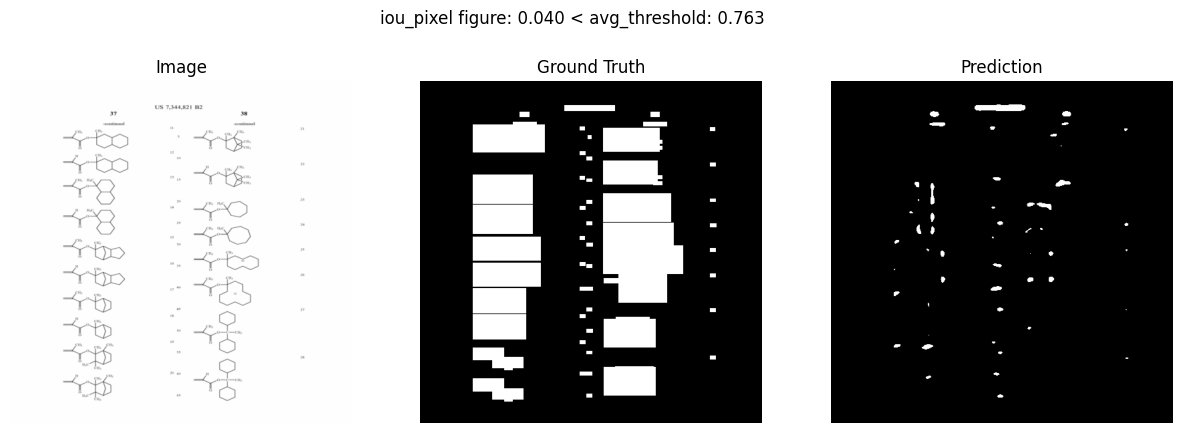

Iterating across all images...:  30%|███       | 30/100 [00:03<00:05, 12.70it/s]

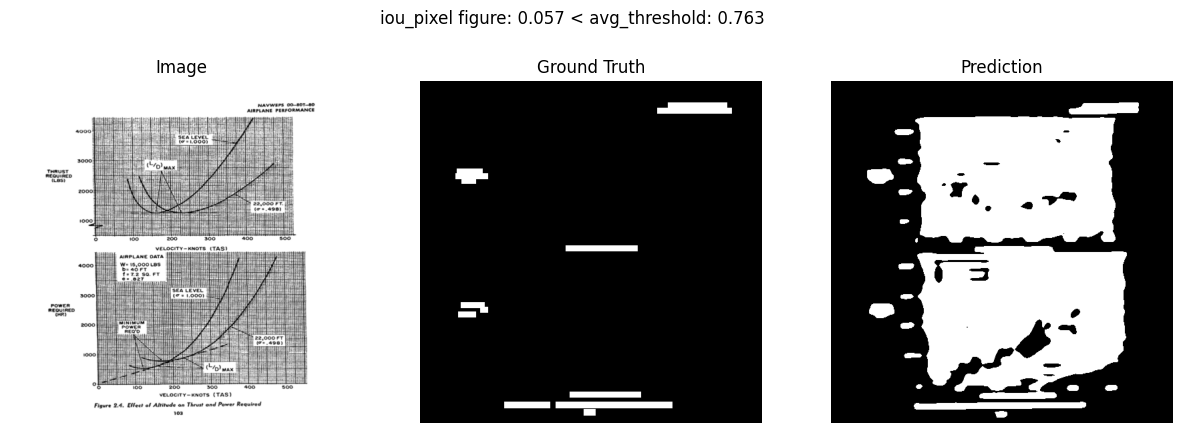

Iterating across all images...:  32%|███▏      | 32/100 [00:03<00:06, 10.92it/s]

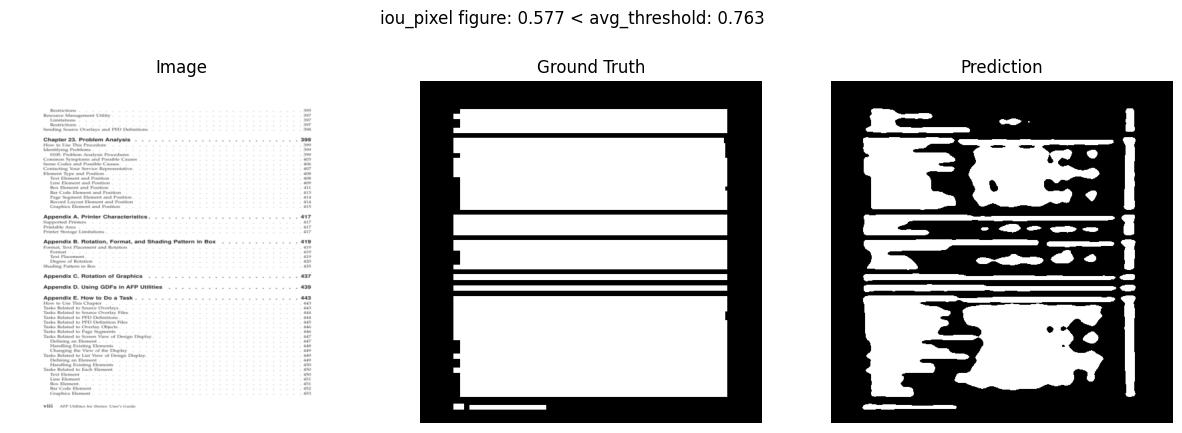

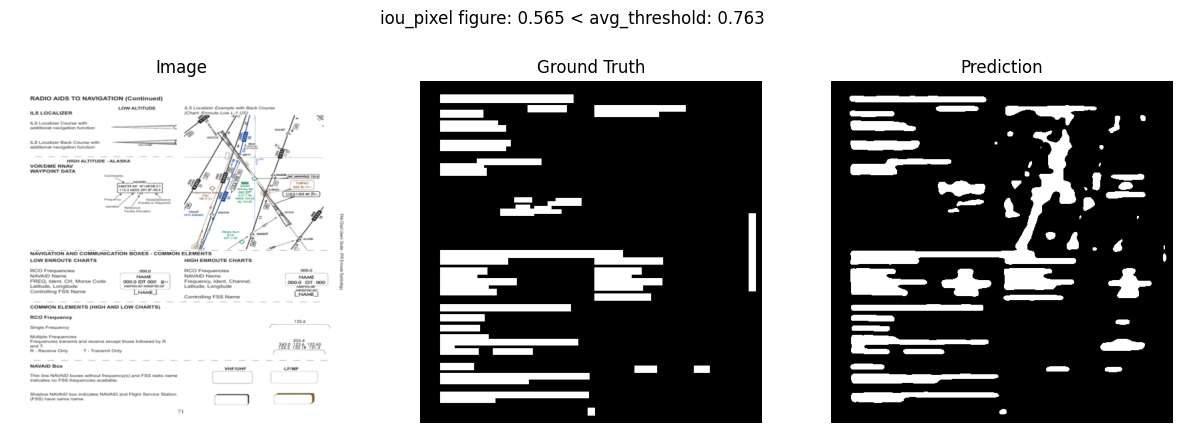

Iterating across all images...:  34%|███▍      | 34/100 [00:04<00:08,  7.44it/s]

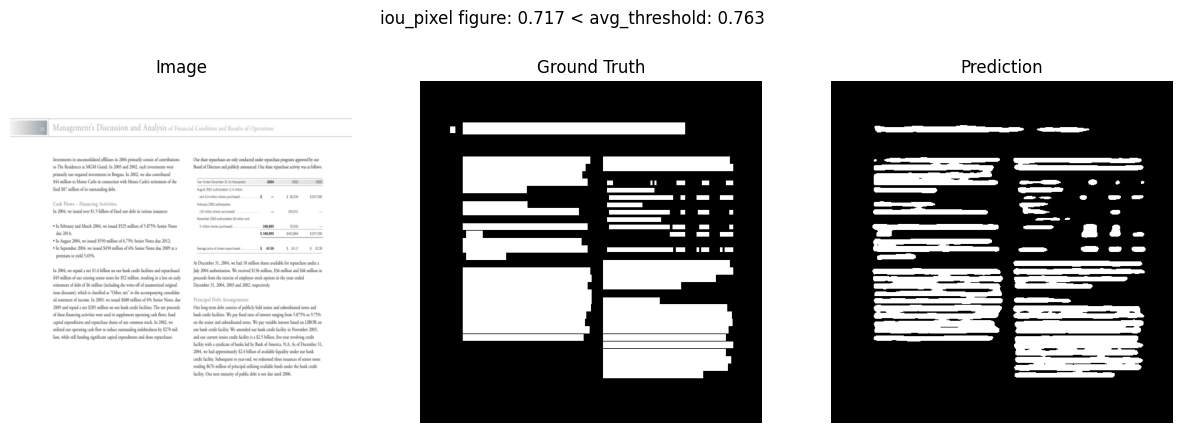

Iterating across all images...:  37%|███▋      | 37/100 [00:04<00:07,  8.24it/s]

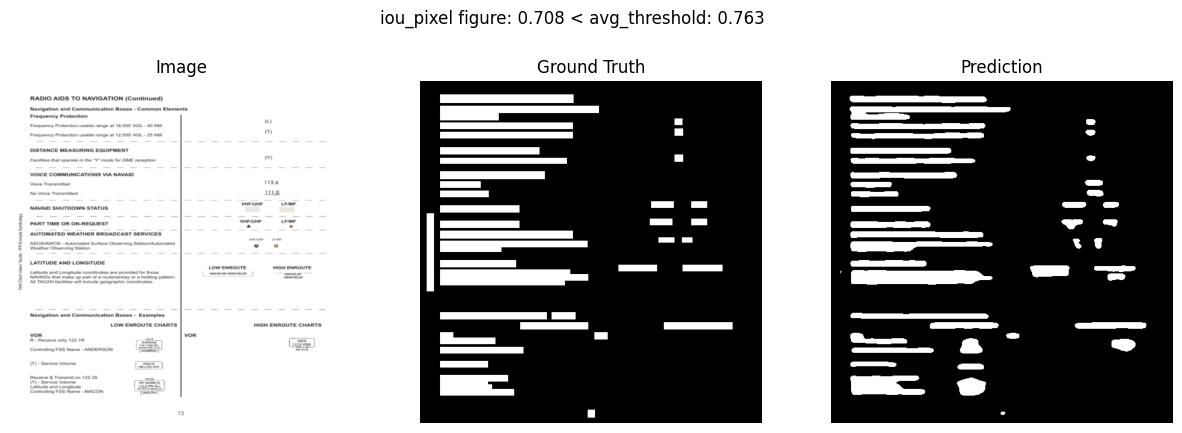

Iterating across all images...:  41%|████      | 41/100 [00:04<00:06,  9.60it/s]

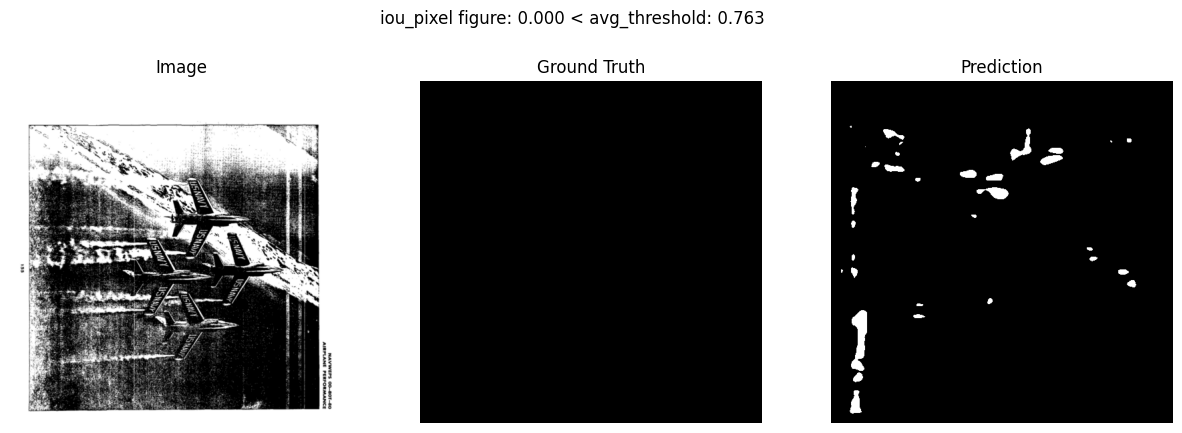

Iterating across all images...:  43%|████▎     | 43/100 [00:04<00:06,  8.81it/s]

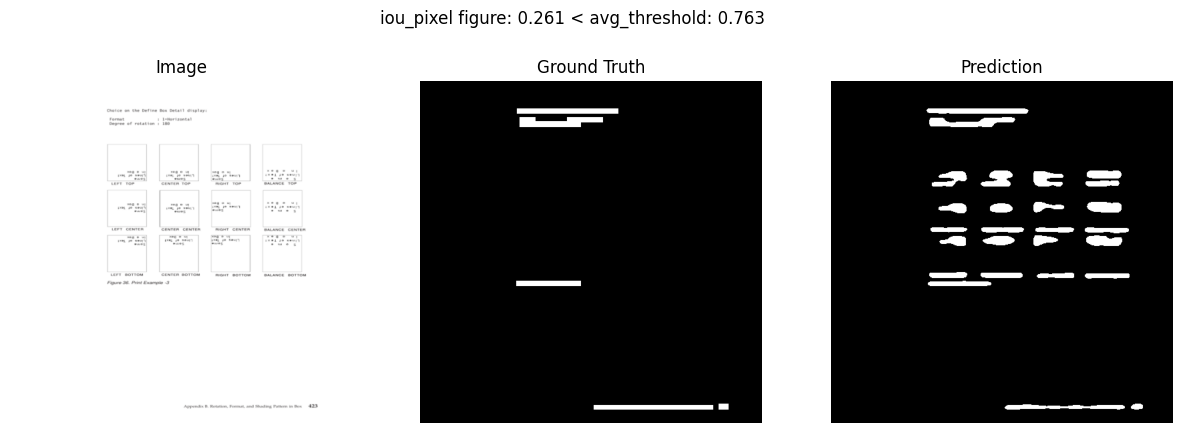

Iterating across all images...:  53%|█████▎    | 53/100 [00:05<00:02, 16.42it/s]

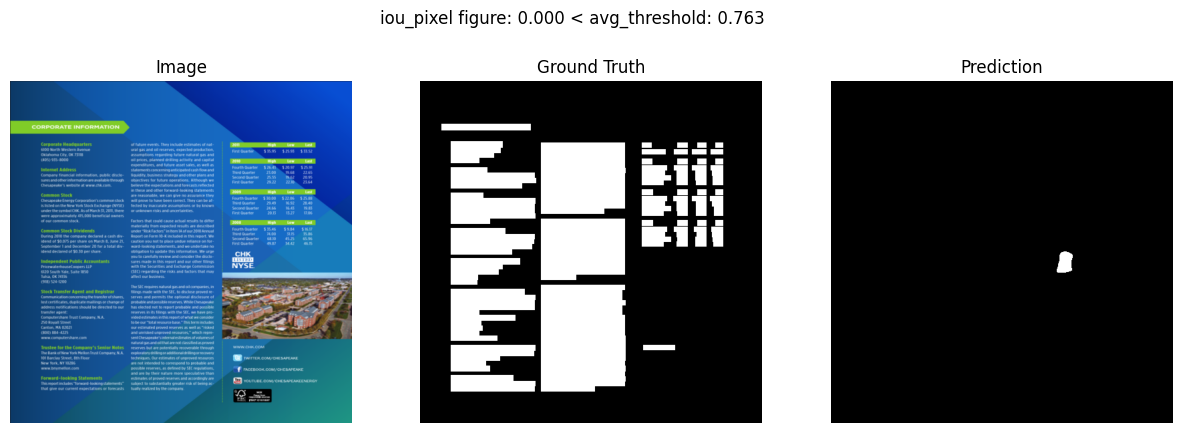

Iterating across all images...:  55%|█████▌    | 55/100 [00:05<00:03, 13.68it/s]

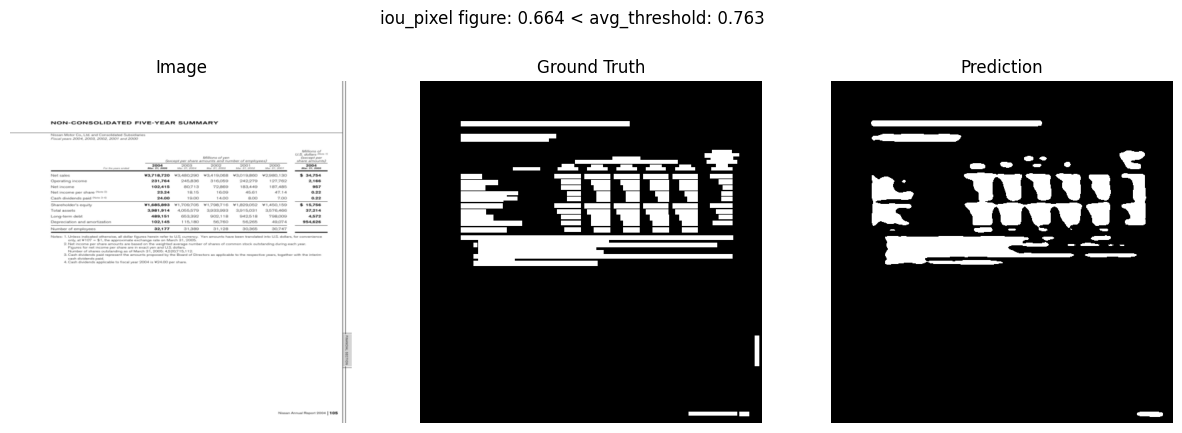

Iterating across all images...:  57%|█████▋    | 57/100 [00:05<00:03, 12.15it/s]

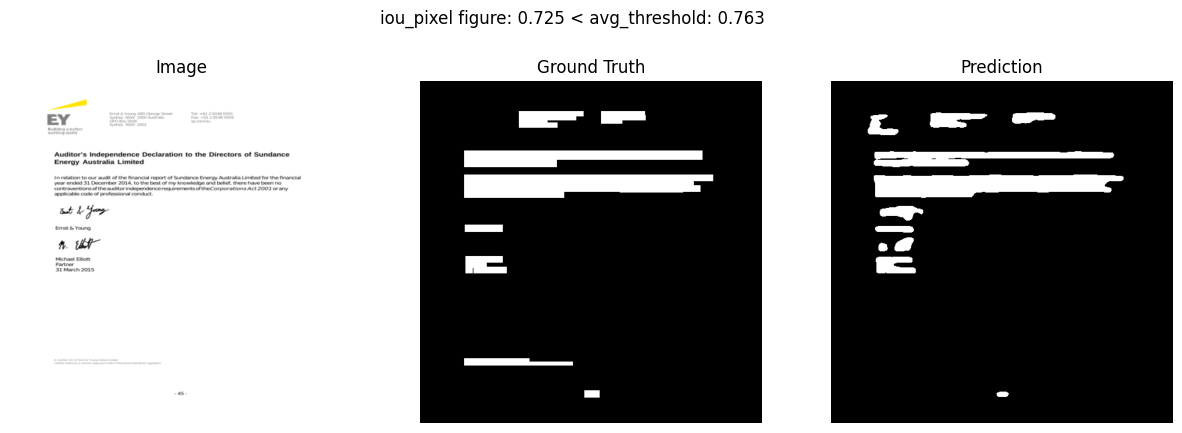

Iterating across all images...:  59%|█████▉    | 59/100 [00:06<00:03, 10.82it/s]

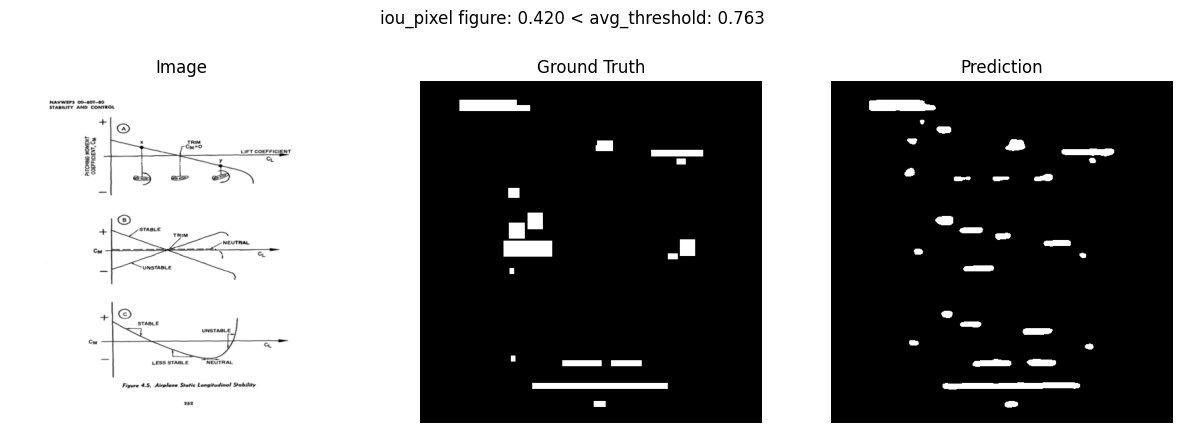

Iterating across all images...:  76%|███████▌  | 76/100 [00:06<00:00, 26.94it/s]

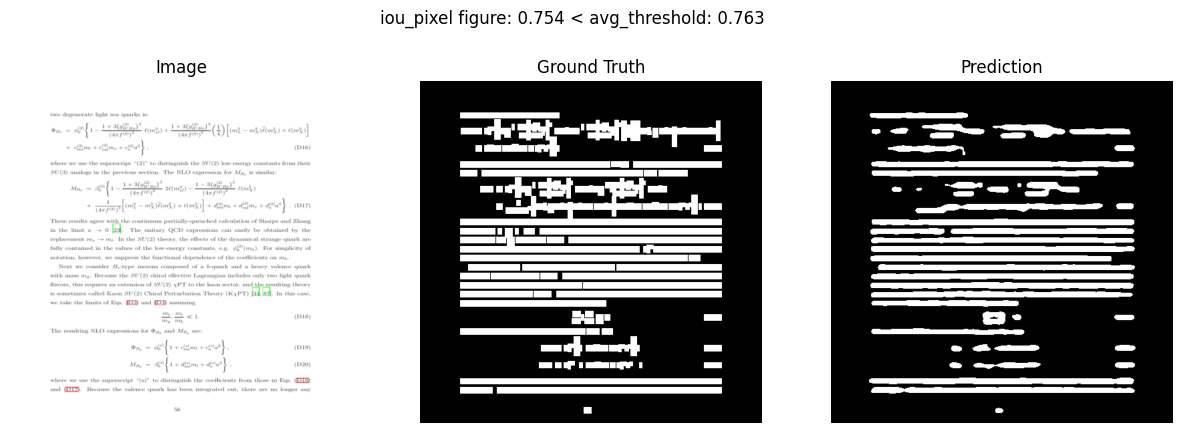

Iterating across all images...:  79%|███████▉  | 79/100 [00:06<00:00, 22.99it/s]

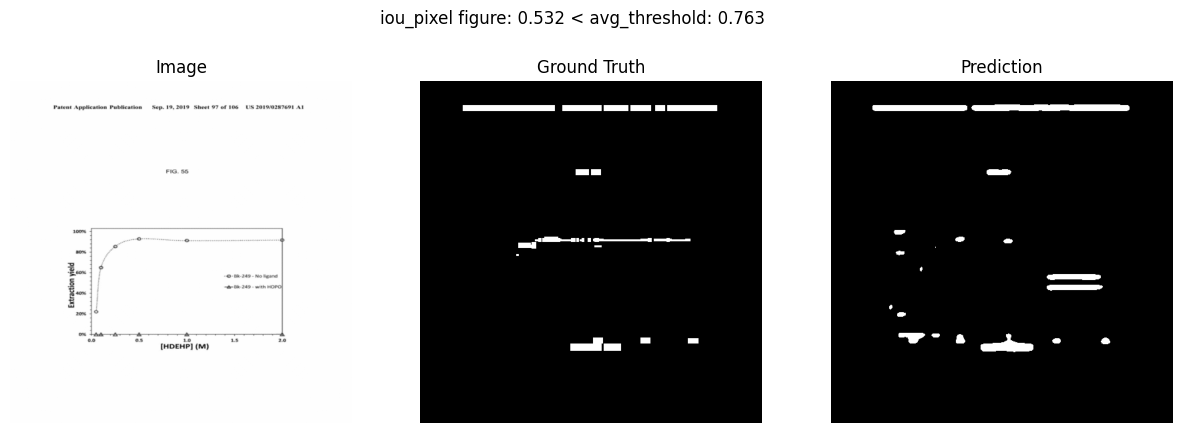

Iterating across all images...:  83%|████████▎ | 83/100 [00:06<00:00, 20.58it/s]

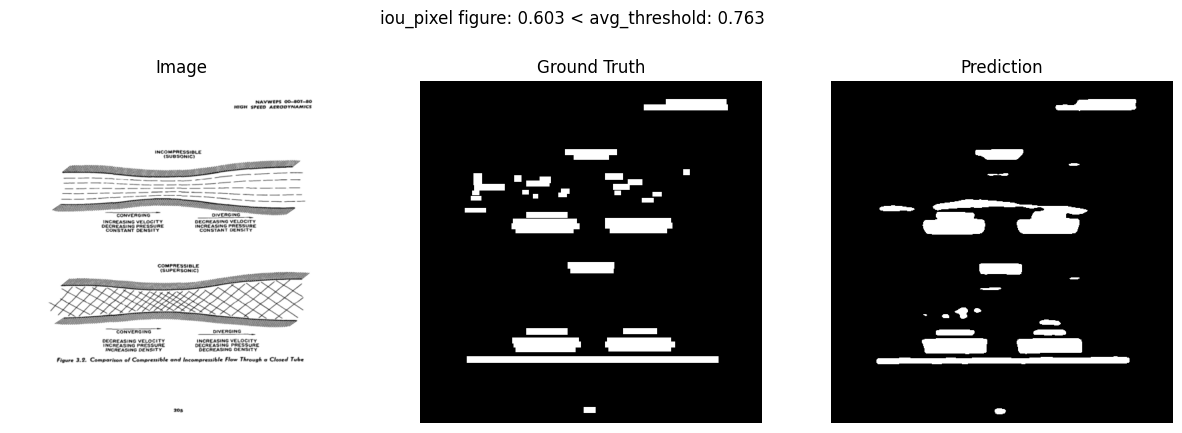

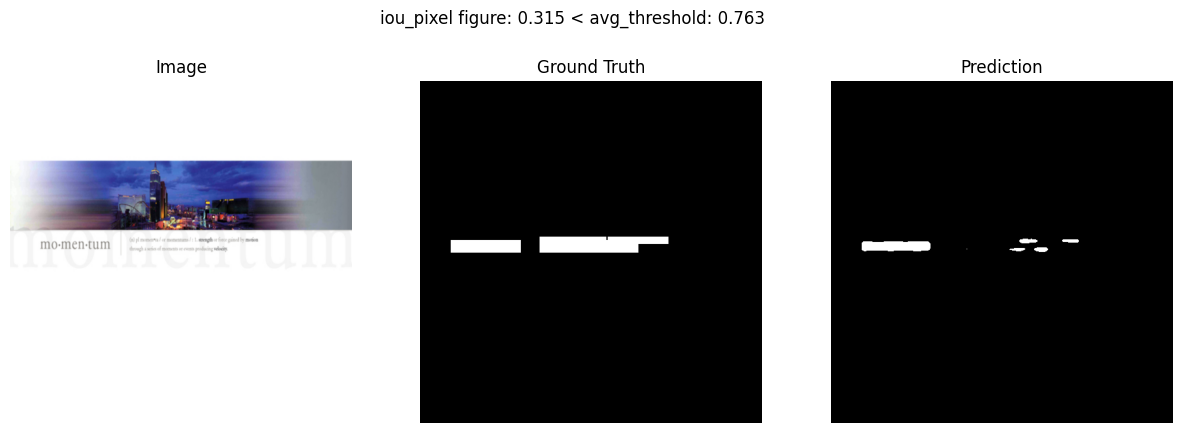

Iterating across all images...:  86%|████████▌ | 86/100 [00:07<00:01, 13.86it/s]

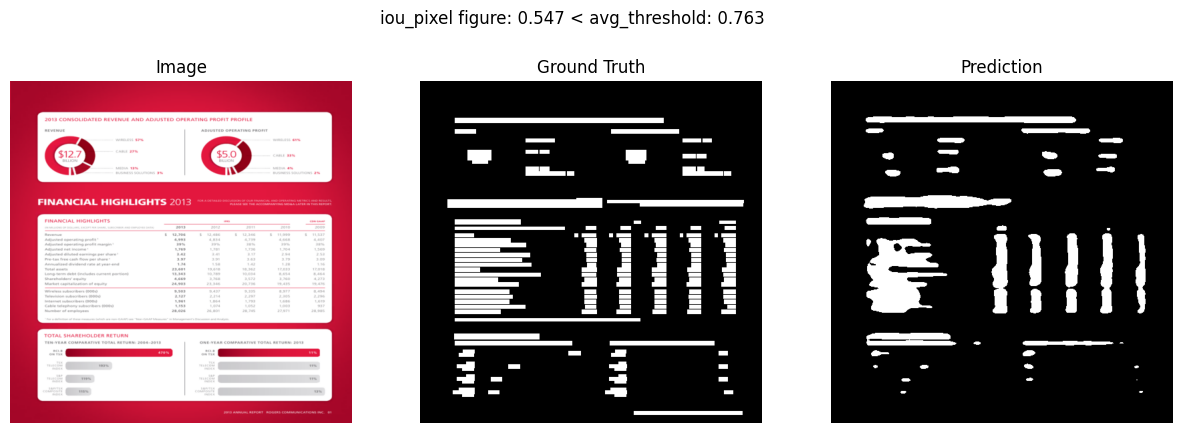

Iterating across all images...:  89%|████████▉ | 89/100 [00:07<00:00, 12.61it/s]

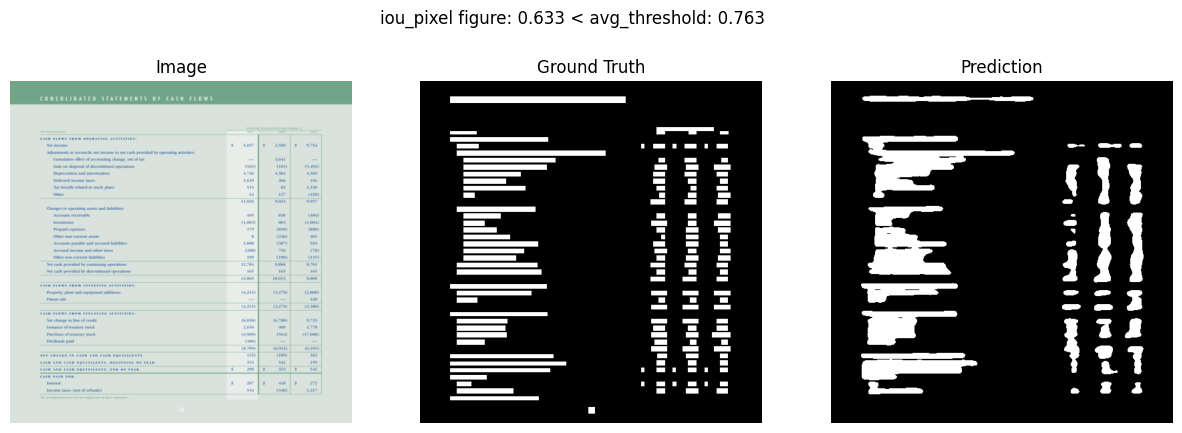

Iterating across all images...:  92%|█████████▏| 92/100 [00:07<00:00, 12.26it/s]

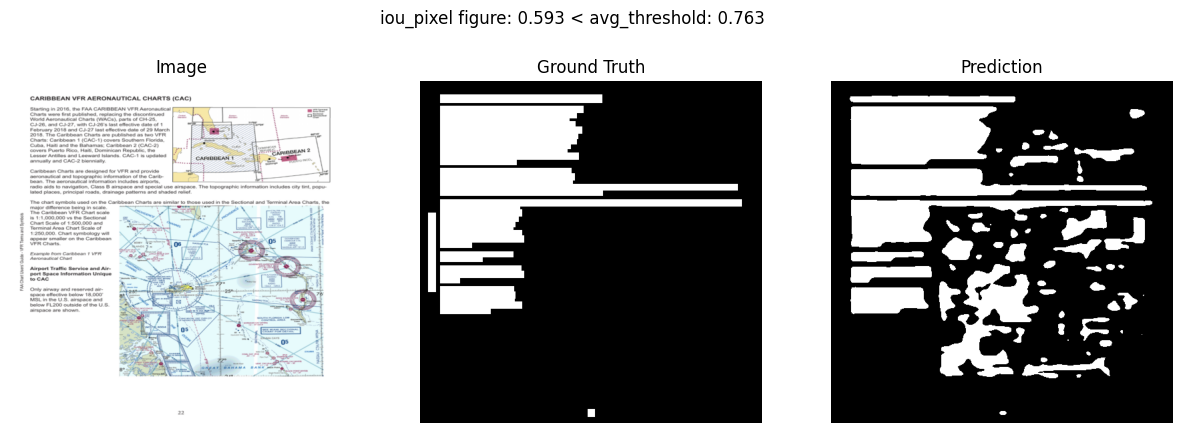

Iterating across all images...:  95%|█████████▌| 95/100 [00:08<00:00,  8.98it/s]

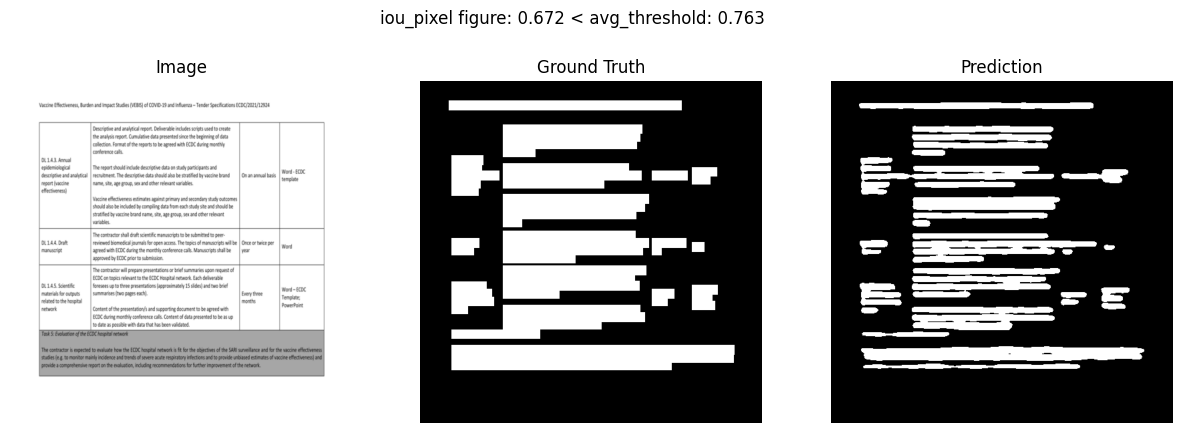

Iterating across all images...: 100%|██████████| 100/100 [00:08<00:00, 11.50it/s]


In [89]:
# Let's plot the worst images jejejejje
plot_worst_images(num_metrics=numeric_metrics,
                  avg_metrics=average_metrics,
                  total_imgs=total_metrics["imgs"],
                  total_masks=total_metrics["masks"],
                  total_logits=total_metrics["logits"],
                  key_metric="iou_pixel")